Original Data:
    Feature1  Feature2
0        10       200
1        20       190
2        30       180
3        40       170
4        50       160

Scaled Data:
    Feature1  Feature2
0 -1.414214  1.414214
1 -0.707107  0.707107
2  0.000000  0.000000
3  0.707107 -0.707107
4  1.414214 -1.414214


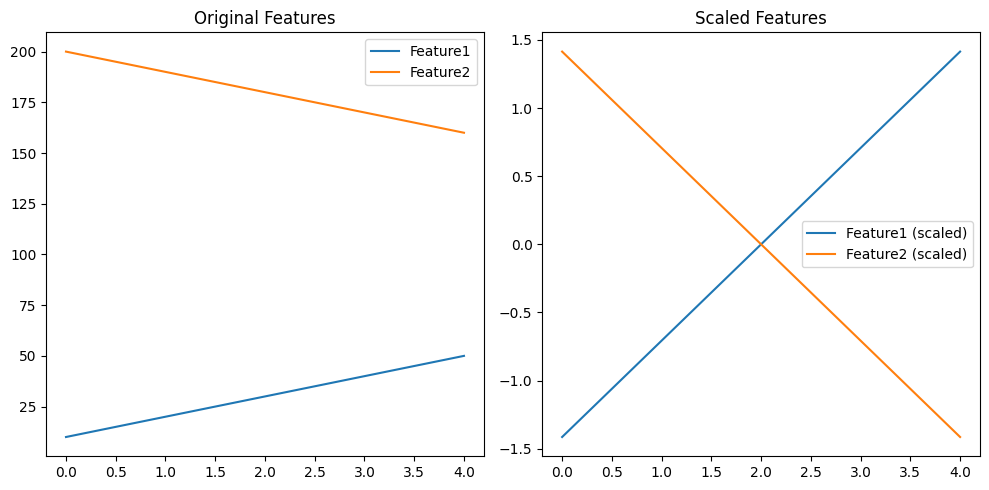

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# 3. Create a sample dataset
data = pd.DataFrame({
'Feature1': [10, 20, 30, 40, 50], # e.g., pixel count of an object
'Feature2': [200, 190, 180, 170, 160] # e.g., texture intensity
})
# 4. Apply standard scaling (Z-score normalization)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
# 5. Create a new DataFrame for scaled data
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
# 6. Display original vs scaled data
print("Original Data:\n", data)
print("\nScaled Data:\n", scaled_df)
# 7. Visualize the difference
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Features")
plt.plot(data['Feature1'], label='Feature1')
plt.plot(data['Feature2'], label='Feature2')
plt.legend()
plt.subplot(1, 2, 2)
plt.title("Scaled Features")
plt.plot(scaled_df['Feature1'], label='Feature1 (scaled)')

plt.plot(scaled_df['Feature2'], label='Feature2 (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


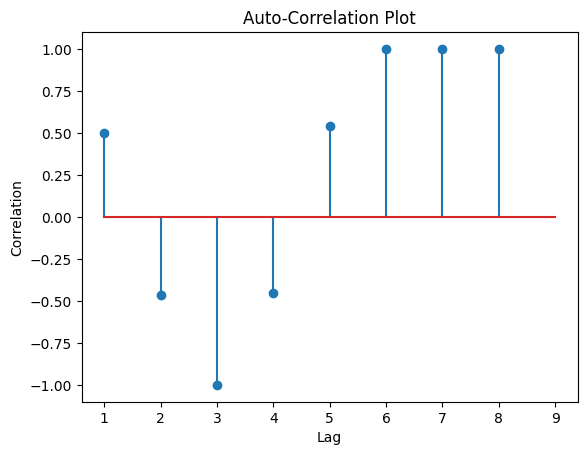

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
# Simulated signal
data = pd.Series([1, 2, 3, 4, 3, 2, 1, 2, 3, 4])
autocorrelation = [data.autocorr(lag=i) for i in range(1, len(data))]
plt.stem(range(1, len(data)), autocorrelation)
plt.title("Auto-Correlation Plot")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

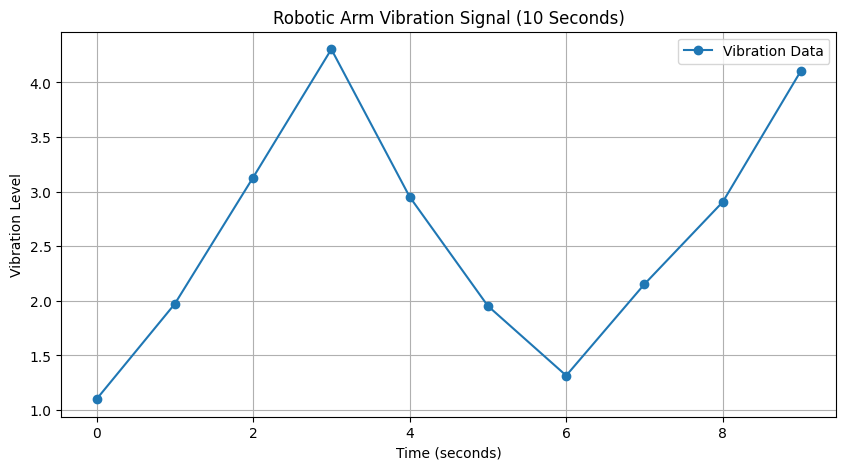

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 1000x500 with 0 Axes>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# --- Simulate Vibration Sensor Data (10 seconds) ---
# Create a pattern that mimics a repeating stress cycle
# Add minor noise to simulate realistic sensor behavior
np.random.seed(42) # For reproducibility
base_pattern = [1, 2, 3, 4, 3, 2, 1, 2, 3, 4] # Ideal cycle
noise = np.random.normal(0, 0.2, len(base_pattern)) # Small noise
vibration_data = np.array(base_pattern) + noise
# Convert to pandas Series
data = pd.Series(vibration_data)
# --- Autocorrelation Calculation ---
autocorrelation = [data.autocorr(lag=i) for i in range(1, len(data))]
# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(data, marker='o', label='Vibration Data')
plt.title("Robotic Arm Vibration Signal (10 Seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Vibration Level")
plt.grid(True)
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
plt.stem(range(1, len(data)), autocorrelation, basefmt=" ", use_line_collection=True)
plt.title("Autocorrelation of Vibration Signal")
plt.xlabel("Lag (seconds)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Sample patient data
data = {
'HeartRate_bpm': [72, 88, 60, 102, 77],
'Temperature_C': [36.6, 37.8, 36.1, 38.2, 37.0],
'BloodPressure_mmHg': [120, 135, 110, 145, 125]
}
df = pd.DataFrame(data)
# Apply Standard Scaling
scaler = StandardScaler()
normalized_data = scaler.fit_transform(df)
# Show result
normalized_df = pd.DataFrame(normalized_data, columns=df.columns)
print("Normalized Patient Data:")
print(normalized_df)

Normalized Patient Data:
   HeartRate_bpm  Temperature_C  BloodPressure_mmHg
0      -0.545895      -0.702782           -0.579324
1       0.573890       0.858956            0.662085
2      -1.385734      -1.353506           -1.406930
3       1.553702       1.379535            1.489691
4      -0.195962      -0.182203           -0.165521


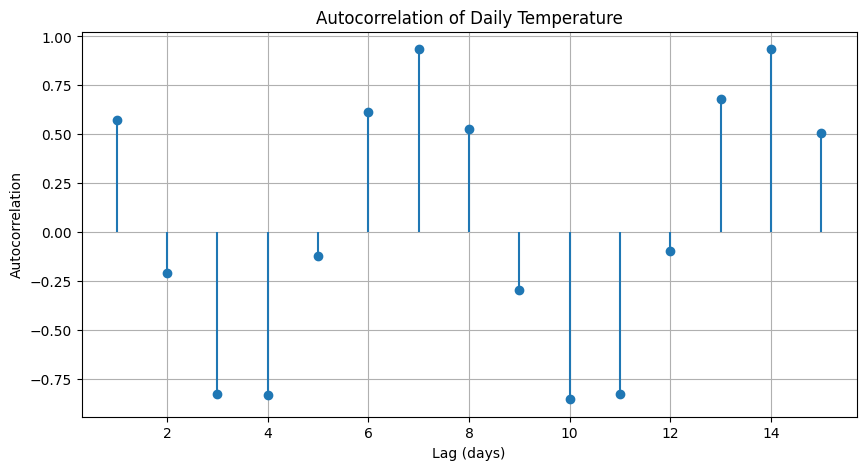

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Simulated 30-day daily temperature data (in °C)
np.random.seed(0)
days = 30
temperature = 20 + 5 * np.sin(2 * np.pi * np.arange(days) / 7) + np.random.normal(0, 1, days)
temp_series = pd.Series(temperature)
# Calculate autocorrelation for lags 1 to 15
autocorr_values = [temp_series.autocorr(lag=i) for i in range(1, 16)]
# Plot autocorrelation
plt.figure(figsize=(10, 5))
plt.stem(range(1, 16), autocorr_values, basefmt=" ")
plt.title("Autocorrelation of Daily Temperature")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# Sample credit data
data = {
'CreditHistoryScore': [650, 700, 620, 800, 720],
'Income_k': [30, 45, 25, 70, 50],
'Age': [25, 35, 22, 45, 33],
'LoanApproved': [0, 1, 0, 1, 1]
}
df = pd.DataFrame(data)
X = df[['CreditHistoryScore', 'Income_k', 'Age']]
y = df['LoanApproved']
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Train Logistic Regression with feature importance
model = LogisticRegression()
model.fit(X_scaled, y)
# Show feature weights
coefficients = pd.Series(model.coef_[0], index=X.columns)
print("Feature Weights (Logistic Regression):")
print(coefficients.sort_values(ascending=False))

Feature Weights (Logistic Regression):
Age                   0.649174
Income_k              0.622297
CreditHistoryScore    0.588569
dtype: float64
